# 1. Import packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

C:\Users\Utilizador\anaconda3\envs\diabetes\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Data loading

In [2]:
try:
    path = kagglehub.dataset_download("imtkaggleteam/diabetes")
    file = os.path.join(path, 'diabetes.csv')

    df = pd.read_csv(file)
    print("Shape: ", df.shape)
    print(path)
    display(df.head(20))
    
except Exception as e:
    print(f"Error: {e}")

Shape:  (403, 19)
C:\Users\Utilizador\.cache\kagglehub\datasets\imtkaggleteam\diabetes\versions\1


,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0
5,1008,248.0,94,69.0,3.6,4.81,Buckingham,34,male,71.0,190.0,large,132.0,86.0,NaN,NaN,36.0,42.0,195.0
6,1011,195.0,92,41.0,4.8,4.84,Buckingham,30,male,69.0,191.0,medium,161.0,112.0,161.0,112.0,46.0,49.0,720.0
7,1015,227.0,75,44.0,5.2,3.94,Buckingham,37,male,59.0,170.0,medium,NaN,NaN,NaN,NaN,34.0,39.0,1020.0
8,1016,177.0,87,49.0,3.6,4.84,Buckingham,45,male,69.0,166.0,large,160.0,80.0,128.0,86.0,34.0,40.0,300.0
9,1022,263.0,89,40.0,6.6,5.78,Buckingham,55,female,63.0,202.0,small,108.0,72.0,NaN,NaN,45.0,50.0,240.0


# 3. Preprocessing

In [3]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('.', '_')
df = df.drop_duplicates()

if 'id' in df.columns:
    df = df.drop(columns=['id'])

In [4]:
cols = df.select_dtypes(include='string').columns
for col in cols:
    df[col] = df[col].str.strip().str.lower()

df.head(5)

,chol,stab_glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp_1s,bp_1d,bp_2s,bp_2d,waist,hip,time_ppn
0,203.0,82,56.0,3.6,4.31,buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,165.0,97,24.0,6.9,4.44,buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,228.0,92,37.0,6.2,4.64,buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,78.0,93,12.0,6.5,4.63,buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,249.0,90,28.0,8.9,7.72,buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


In [5]:
bins = [0, 35, 50, 65, 100]
labels = ['<35', '35-50', '51-65', '>65']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# 4. Data Overview

In [6]:
print("Rows: ", df.shape[0])
print("Columns: ", df.shape[1])
print("Duplicate rows: ", df.duplicated().sum())
print("Total missing values: ", df.isna().sum().sum())

display(df.dtypes.to_frame("Data_Type"))
df.describe(include="all").T

Rows:  403
Columns:  19
Duplicate rows:  0
Total missing values:  575


,Data_Type
chol,float64
stab_glu,int64
hdl,float64
ratio,float64
glyhb,float64
location,str
age,int64
gender,str
height,float64
weight,float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
chol,402.0,NaN,NaN,NaN,207.845771,44.445557,78.0,179.0,204.0,230.0,443.0
stab_glu,403.0,NaN,NaN,NaN,106.672457,53.076655,48.0,81.0,89.0,106.0,385.0
hdl,402.0,NaN,NaN,NaN,50.445274,17.262626,12.0,38.0,46.0,59.0,120.0
ratio,402.0,NaN,NaN,NaN,4.521642,1.727886,1.5,3.2,4.2,5.4,19.299999
glyhb,390.0,NaN,NaN,NaN,5.589769,2.242595,2.68,4.38,4.84,5.6,16.110001
location,403,2,louisa,203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,403.0,NaN,NaN,NaN,46.851117,16.312333,19.0,34.0,45.0,60.0,92.0
gender,403,2,female,234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,398.0,NaN,NaN,NaN,66.020101,3.918515,52.0,63.0,66.0,69.0,76.0
weight,402.0,NaN,NaN,NaN,177.59204,40.340666,99.0,151.0,172.5,200.0,325.0


In [7]:
df.isna().sum()

chol           1
stab_glu       0
hdl            1
ratio          1
glyhb         13
location       0
age            0
gender         0
height         5
weight         1
frame         12
bp_1s          5
bp_1d          5
bp_2s        262
bp_2d        262
waist          2
hip            2
time_ppn       3
age_group      0
dtype: int64

In [8]:
df['glyhb_imputed'] = df.groupby('age_group')['glyhb'].transform(lambda x: x.fillna(x.median()))

In [9]:
df['bp_1s_imputed'] = df.groupby('age_group')['bp_1s'].transform(lambda x: x.fillna(x.median()))

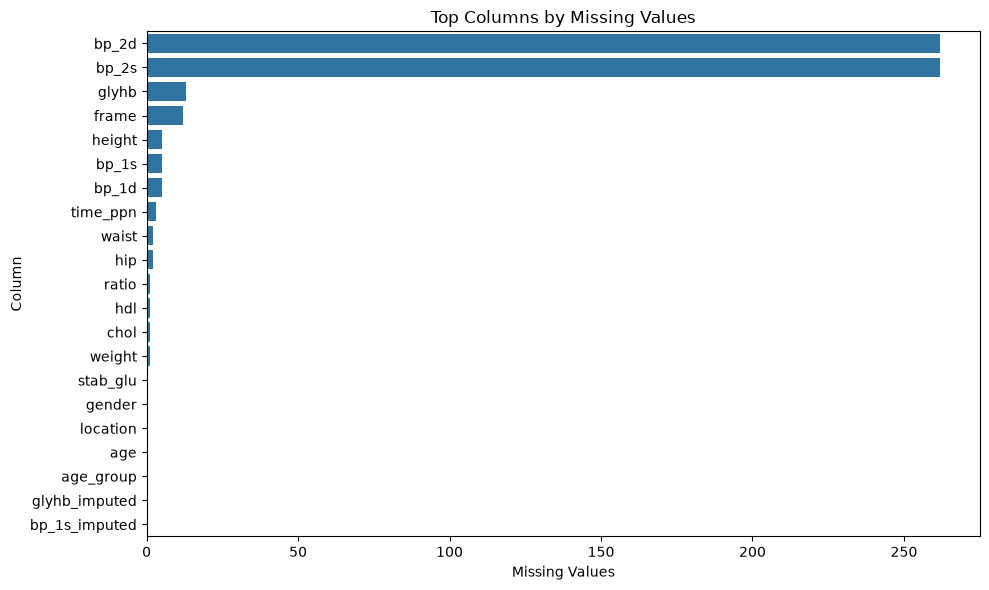

In [10]:
plt.figure(figsize=(10,6))
sns.barplot(
        x=df.isna().sum().sort_values(ascending = False).values,
        y=df.isna().sum().sort_values(ascending = False).index)
plt.title("Top Columns by Missing Values")
plt.xlabel("Missing Values")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

In [11]:
if 'bp_2s' in df.columns:
    df = df.drop(columns=['bp_2s'])

if 'bp_2d' in df.columns:
    df = df.drop(columns=['bp_2d'])

# 5. Correlation Analysis

## 5.1. Heatmap overall view

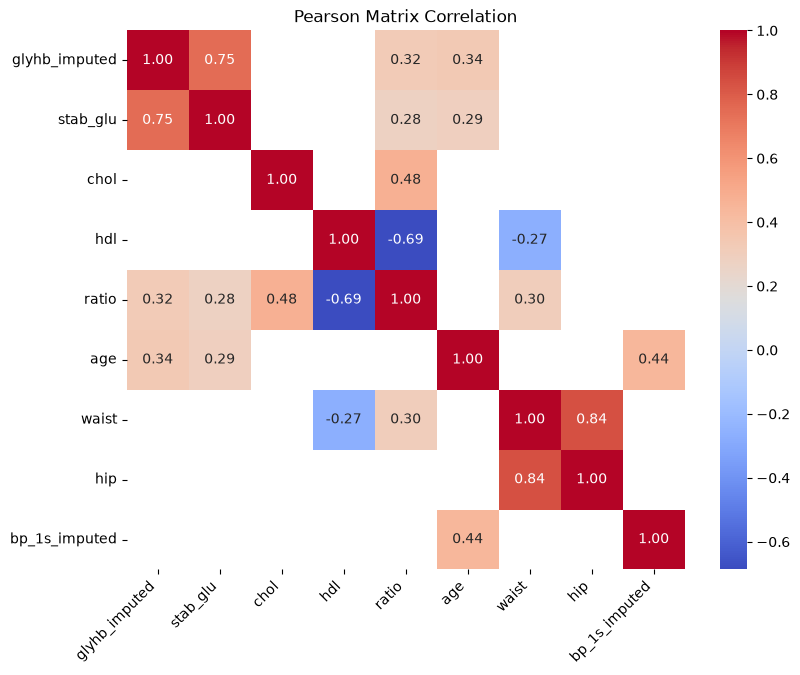

In [21]:
cols = ['glyhb_imputed', 'stab_glu', 'chol', 'hdl', 'ratio', 'age', 'waist', 'hip', 'bp_1s_imputed']

plt.figure(figsize=(9, 7))
corr = df[cols].corr()
sns.heatmap(corr[corr.abs() > 0.25], annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pearson Matrix Correlation")
plt.xticks(rotation=45, ha='right')
plt.show()

## 5.2. Histogram of Glycated Hemoglobin, Stabilized Glucose and Systolic Bloob Pressure 1st

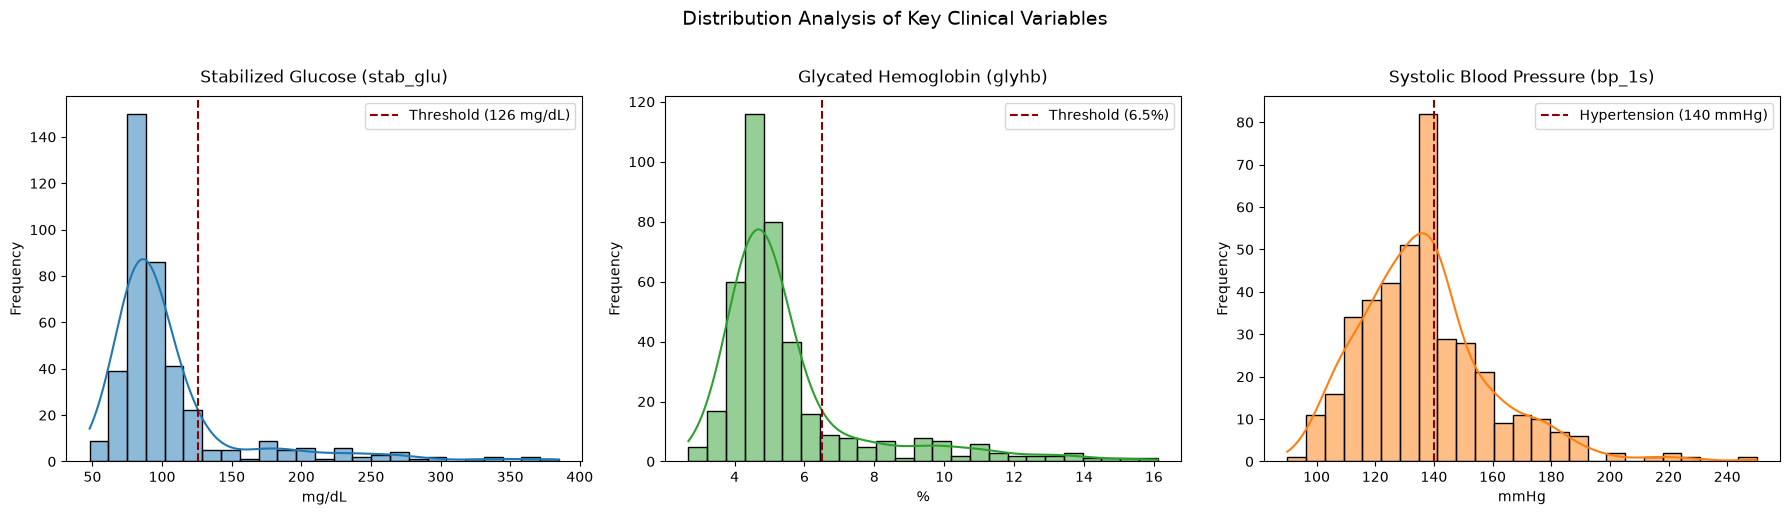

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. stab_glu histograma
sns.histplot(df['stab_glu'], kde=True, ax=axes[0], color='#1f77b4', bins=25)
axes[0].axvline(126, color='darkred', linestyle='--', linewidth=1.5, label='Threshold (126 mg/dL)')
axes[0].set_title('Stabilized Glucose (stab_glu)', fontsize=12, pad=10)
axes[0].set_xlabel('mg/dL', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].legend()

# 2. glyhb histogram 
sns.histplot(df['glyhb_imputed'], kde=True, ax=axes[1], color='#2ca02c', bins=25)
axes[1].axvline(6.5, color='darkred', linestyle='--', linewidth=1.5, label='Threshold (6.5%)')
axes[1].set_title('Glycated Hemoglobin (glyhb)', fontsize=12, pad=10)
axes[1].set_xlabel('%', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].legend()

# 3. bp_1s histogram
sns.histplot(df['bp_1s_imputed'], kde=True, ax=axes[2], color='#ff7f0e', bins=25)
axes[2].axvline(140, color='darkred', linestyle='--', linewidth=1.5, label='Hypertension (140 mmHg)')
axes[2].set_title('Systolic Blood Pressure (bp_1s)', fontsize=12, pad=10)
axes[2].set_xlabel('mmHg', fontsize=10)
axes[2].set_ylabel('Frequency', fontsize=10)
axes[2].legend()

plt.suptitle('Distribution Analysis of Key Clinical Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5.3. Linear Regression between Stabilized Glucose and Glycated Hemoglobin

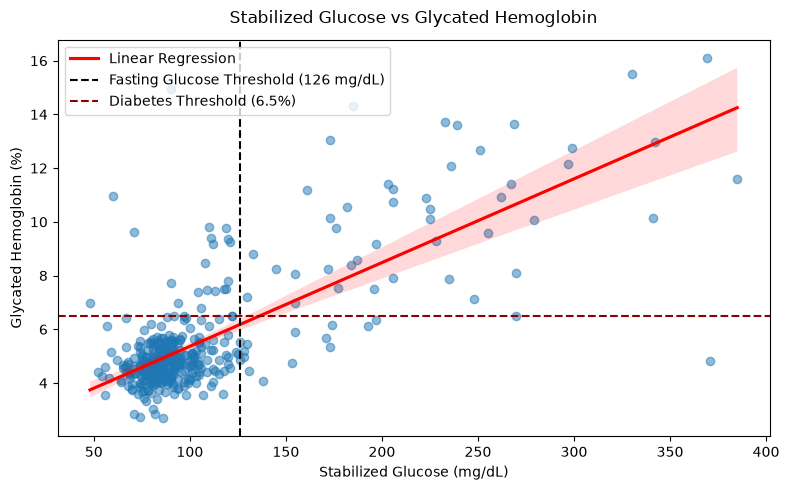

In [23]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df, x='stab_glu', y='glyhb_imputed',
    scatter_kws={'alpha': 0.5, 'color': '#1f77b4'},
    line_kws={'color': 'red', 'label': 'Linear Regression'}
)
plt.axvline(126, color='black', linestyle='--', label='Fasting Glucose Threshold (126 mg/dL)')
plt.axhline(6.5, color='darkred', linestyle='--', label='Diabetes Threshold (6.5%)')

plt.title("Stabilized Glucose vs Glycated Hemoglobin", fontsize=12, pad=12)
plt.xlabel("Stabilized Glucose (mg/dL)", fontsize=10)
plt.ylabel("Glycated Hemoglobin (%)", fontsize=10)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 5.4. Relation between Waist and Glycated Hemoglobin

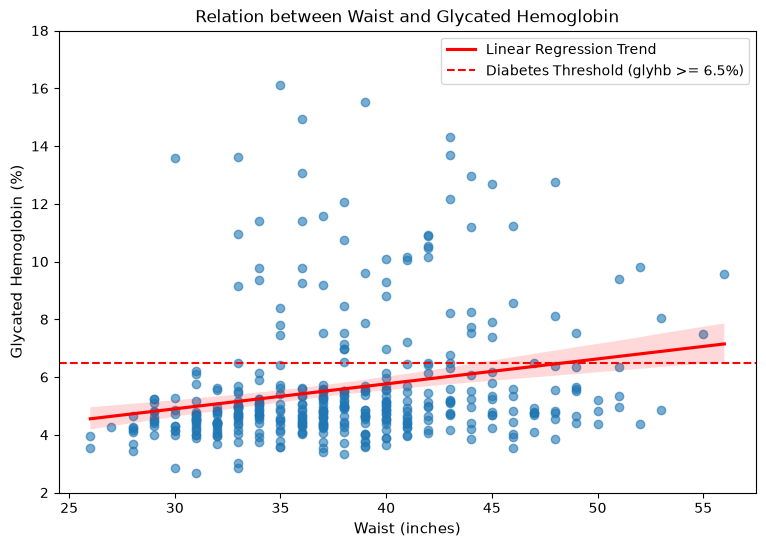

In [15]:
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df, 
    x='waist', 
    y='glyhb_imputed', 
    scatter_kws={'alpha':0.6}, 
    line_kws={'color': 'red', 'label': 'Linear Regression Trend'})

plt.axhline(
    y=6.5, 
    color='red', 
    linestyle='--', 
    linewidth=1.5, 
    label='Diabetes Threshold (glyhb >= 6.5%)')

plt.title("Relation between Waist and Glycated Hemoglobin")
plt.xlabel("Waist (inches)", fontsize=11)
plt.ylabel("Glycated Hemoglobin (%)", fontsize=11)
plt.legend(loc='upper right', frameon=True)
plt.ylim(2, 18)
plt.show()

## 5.5. Glucose Distribution by Diabetic Status

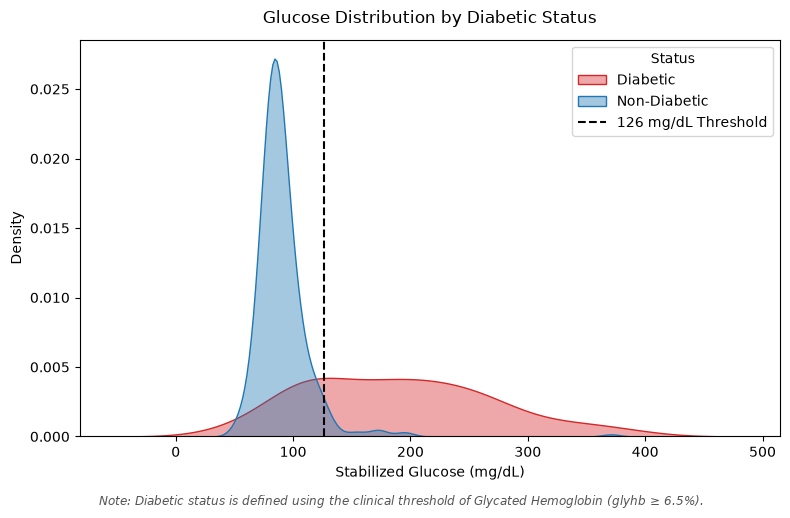

In [16]:
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df, x='stab_glu', hue=df['glyhb_imputed'] >= 6.5, 
    common_norm=False, fill=True, palette={0: '#1f77b4', 1: '#d62728'}, alpha=0.4
)
plt.axvline(126, color='black', linestyle='--', label='Threshold (126 mg/dL)')

plt.figtext(
    0.13, -0.02, 
    "Note: Diabetic status is defined using the clinical threshold of Glycated Hemoglobin (glyhb ≥ 6.5%).", 
    fontsize=8.5, 
    style='italic', 
    color='#555555'
)

plt.title("Glucose Distribution by Diabetic Status", fontsize=12, pad=12)
plt.xlabel("Stabilized Glucose (mg/dL)", fontsize=10)
plt.ylabel("Density", fontsize=10)
plt.legend(title='Status', labels=['Diabetic', 'Non-Diabetic', '126 mg/dL Threshold'])
plt.tight_layout()
plt.show()

## 5.6. Diabetes Prevalence and Mean Blood Pressure by Age Group

In [17]:
df['is_diabetic'] = ((df['glyhb_imputed'] >= 6.5) & (df['stab_glu'] >= 126)).astype(int)

age_summary = df.groupby('age_group', observed=False).agg(
    total_patients=('glyhb_imputed', 'count'),
    mean_bp_1s=('bp_1s_imputed', 'mean'),
    mean_glyhb=('glyhb_imputed', 'mean'),
    diabetes_percentage=('is_diabetic', lambda x: (x.mean() * 100))
).round(2)

print("Key Indicators Summary by Age Group:")
print(age_summary)

Key Indicators Summary by Age Group:
           total_patients  mean_bp_1s  mean_glyhb  diabetes_percentage
age_group                                                             
<35                   102      124.62        4.65                 1.96
35-50                 130      132.73        5.04                 6.92
51-65                 107      146.38        6.64                21.50
>65                    64      148.58        6.34                17.19


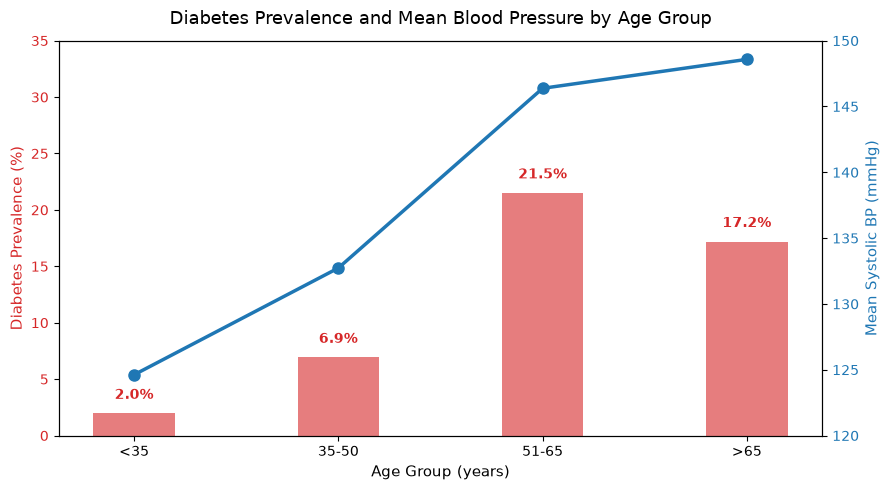

In [18]:
fig, ax1 = plt.subplots(figsize=(9, 5))

color_bar = '#d62728'
ax1.set_xlabel('Age Group (years)', fontsize=11)
ax1.set_ylabel('Diabetes Prevalence (%)', color=color_bar, fontsize=11)
bars = ax1.bar(
    age_summary.index.astype(str), 
    age_summary['diabetes_percentage'], 
    color=color_bar, 
    alpha=0.6, 
    width=0.4
)
ax1.tick_params(axis='y', labelcolor=color_bar)
ax1.set_ylim(0, 35)

for bar in bars:
    yval = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2, 
        yval + 1, 
        f"{yval:.1f}%", 
        ha='center', 
        va='bottom', 
        color=color_bar, 
        weight='bold'
    )

ax2 = ax1.twinx()  
color_line = '#1f77b4'
ax2.set_ylabel('Mean Systolic BP (mmHg)', color=color_line, fontsize=11)
ax2.plot(
    age_summary.index.astype(str), 
    age_summary['mean_bp_1s'], 
    color=color_line, 
    marker='o', 
    linewidth=2.5, 
    markersize=8
)
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(120, 150)

plt.title("Diabetes Prevalence and Mean Blood Pressure by Age Group", fontsize=13, pad=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 5.7. Systolic Blood Pressure Trend Across Age

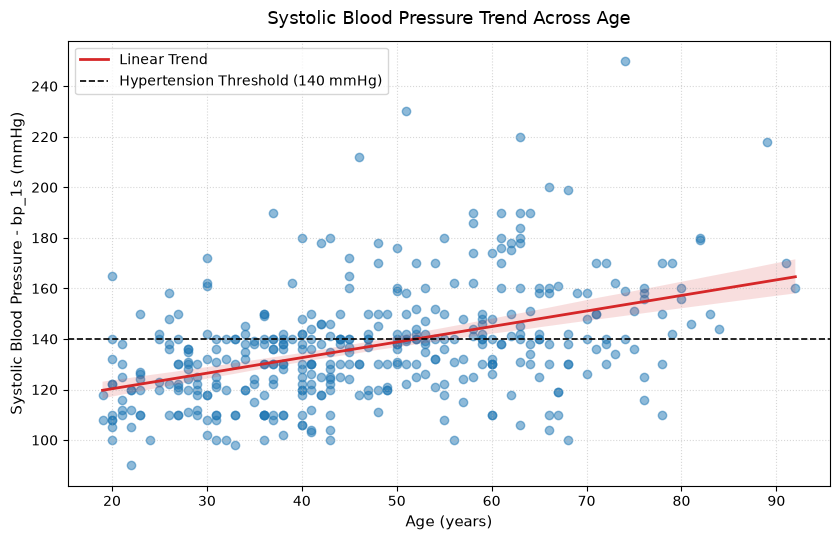

In [19]:
plt.figure(figsize=(8.5, 5.5))

sns.regplot(
    data=df,
    x='age',
    y='bp_1s_imputed',
    scatter_kws={'alpha': 0.5, 'color': '#1f77b4'},
    line_kws={'color': '#d62728', 'linewidth': 2, 'label': 'Linear Trend'}
)

plt.axhline(140, color='black', linestyle='--', linewidth=1.2, label='Hypertension Threshold (140 mmHg)')

plt.title("Systolic Blood Pressure Trend Across Age", fontsize=13, pad=12)
plt.xlabel("Age (years)", fontsize=11)
plt.ylabel("Systolic Blood Pressure - bp_1s (mmHg)", fontsize=11)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# 6. Power BI Script